In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
PARQUET_PATH = r"D:\Griffith College Docs year 2\01 Dissertation\Cleaned-datasets\bikes_cleaned.parquet"

# Load only the columns we actually need for EDA
# This alone cuts memory from 12GB to ~4GB
print("Loading parquet file...")
df = pd.read_parquet(
    PARQUET_PATH,
    columns=["datetime", "station_id", "name", "bikes", "docks", "capacity", "lat", "lon", "hour", "date"]
)

print(f"Loaded: {len(df):,} rows")
print(f"Memory before downcast: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Loading parquet file...
Loaded: 51,259,132 rows
Memory before downcast: 9.46 GB


In [3]:
# ── MEMORY DOWNCAST ──────────────────────────────────────────────────────────
df["datetime"]   = pd.to_datetime(df["datetime"])
df["station_id"] = df["station_id"].astype("int16")
df["bikes"]      = df["bikes"].astype("int8")
df["docks"]      = df["docks"].astype("int8")
df["capacity"]   = df["capacity"].astype("int8")
df["hour"]       = df["hour"].astype("int8")
df["lat"]        = df["lat"].astype("float32")
df["lon"]        = df["lon"].astype("float32")
df["name"]       = df["name"].astype("category")
df["day_of_week"] = df["datetime"].dt.dayofweek.astype("int8")
df["year"]       = df["datetime"].dt.year.astype("int16")
df["month"]      = df["datetime"].dt.month.astype("int8")

print(f"Memory after downcast : {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Unique stations       : {df['station_id'].nunique()}")
print(f"Date range            : {df['datetime'].min()} to {df['datetime'].max()}")
df.head()

Memory after downcast : 4.41 GB
Unique stations       : 117
Date range            : 2019-01-01 00:00:03 to 2026-05-27 15:30:00


,datetime,station_id,name,bikes,docks,capacity,lat,lon,hour,date,day_of_week,year,month
0,2019-01-01 00:00:03,1,CLARENDON ROW,1,30,31,53.340927,-6.262501,0,2019-01-01,1,2019,1
1,2019-01-01 00:00:03,2,BLESSINGTON STREET,1,19,20,53.356770,-6.268140,0,2019-01-01,1,2019,1
2,2019-01-01 00:00:03,3,BOLTON STREET,7,13,20,53.351181,-6.269859,0,2019-01-01,1,2019,1
3,2019-01-01 00:00:03,4,GREEK STREET,6,14,20,53.346874,-6.272976,0,2019-01-01,1,2019,1
4,2019-01-01 00:00:03,5,CHARLEMONT PLACE,28,12,40,53.330662,-6.260177,0,2019-01-01,1,2019,1


## 1. Basic Statistics

In [4]:
# Overall stats
print("=== OVERALL STATISTICS ===")
print(df[["bikes", "docks", "capacity"]].describe().round(2))

# Stock-out and fullness event rates
total = len(df)
stockouts = (df["bikes"] == 0).sum()
fullness  = (df["docks"] == 0).sum()
print(f"\nStock-out events (bikes=0) : {stockouts:,} ({stockouts/total*100:.2f}% of readings)")
print(f"Fullness events (docks=0)  : {fullness:,}  ({fullness/total*100:.2f}% of readings)")

=== OVERALL STATISTICS ===
             bikes        docks     capacity
count  51259132.00  51259132.00  51259132.00
mean         11.70        20.24        32.04
std           9.53        10.96         7.57
min           0.00         0.00        16.00
25%           4.00        12.00        29.00
50%          10.00        20.00        30.00
75%          18.00        29.00        40.00
max          40.00        40.00        40.00

Stock-out events (bikes=0) : 4,858,306 (9.48% of readings)
Fullness events (docks=0)  : 1,590,594  (3.10% of readings)


## 2. Hourly Demand Pattern

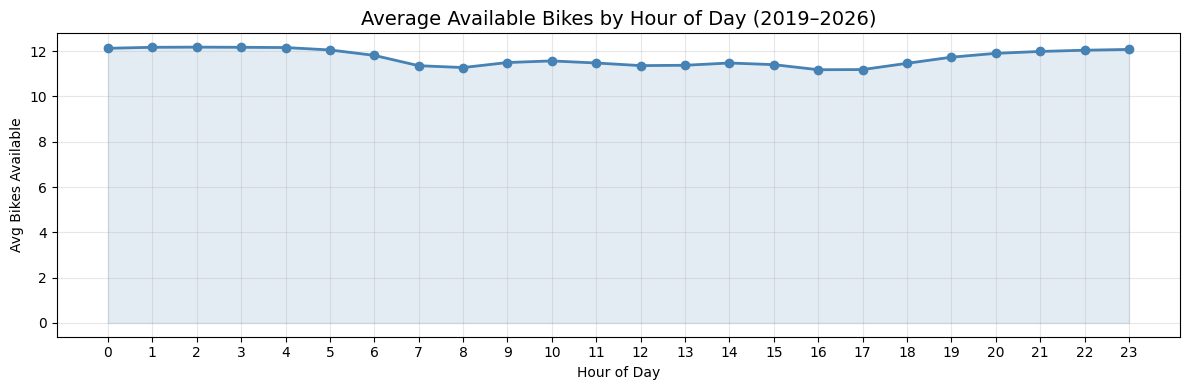

In [5]:
hourly = df.groupby("hour")["bikes"].mean()

plt.figure(figsize=(12, 4))
plt.plot(hourly.index, hourly.values, marker="o", color="steelblue", linewidth=2)
plt.fill_between(hourly.index, hourly.values, alpha=0.15, color="steelblue")
plt.title("Average Available Bikes by Hour of Day (2019–2026)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Avg Bikes Available")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Calculating avg bikes by hour in both weekdays and weekends (This section sometimes crashes due to RAM memory allocation)

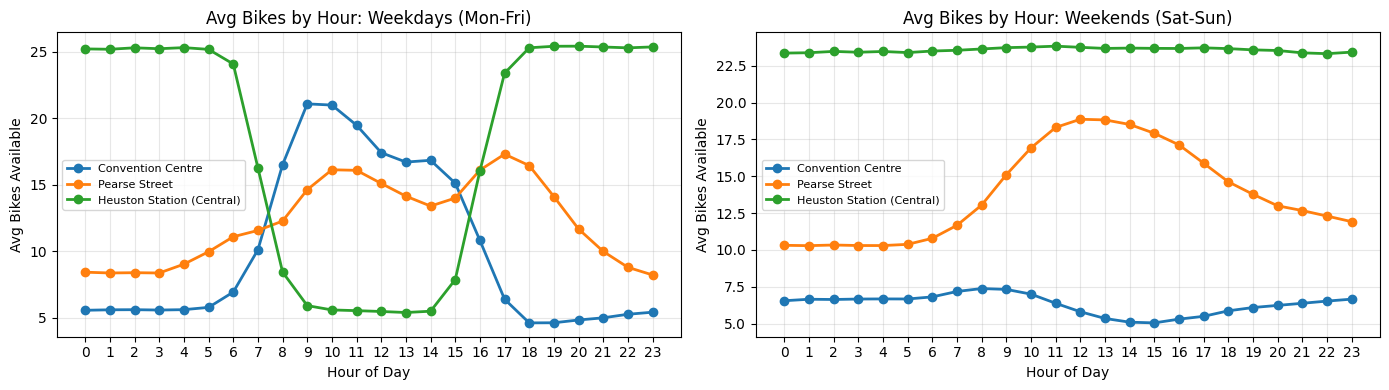

In [6]:
# Convert once outside the loop, not 6 times inside it
df["name_str"] = df["name"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

stations = ["CONVENTION CENTRE", "PEARSE STREET", "HEUSTON STATION (CENTRAL)"]

for ax, (label, day_filter) in zip(axes, [
    ("Weekdays (Mon-Fri)", df["day_of_week"] < 5),
    ("Weekends (Sat-Sun)", df["day_of_week"] >= 5)
]):
    subset = df[day_filter]   # filter once per day type
    for station in stations:
        station_data = subset[subset["name_str"] == station]
        if len(station_data) > 0:
            hourly = station_data.groupby("hour")["bikes"].mean()
            ax.plot(hourly.index, hourly.values, marker="o",
                   label=station.title(), linewidth=2)

    ax.set_title(f"Avg Bikes by Hour: {label}", fontsize=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Avg Bikes Available")
    ax.set_xticks(range(0, 24))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

df.drop(columns=["name_str"], inplace=True)

## 3. Heatmap showing Availability by Day and Hour

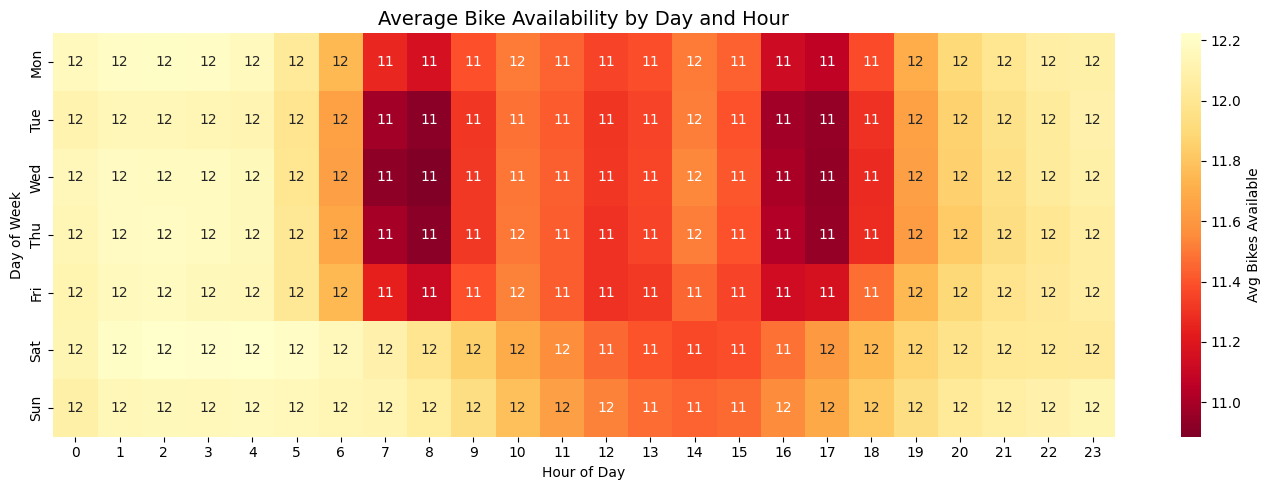

In [7]:
pivot = df.groupby(["day_of_week", "hour"])["bikes"].mean().unstack()
pivot.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap="YlOrRd_r", annot=True, fmt=".0f",
            cbar_kws={"label": "Avg Bikes Available"})
plt.title("Average Bike Availability by Day and Hour", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

## 4. Top 20 Stations by Stock-Out Frequency

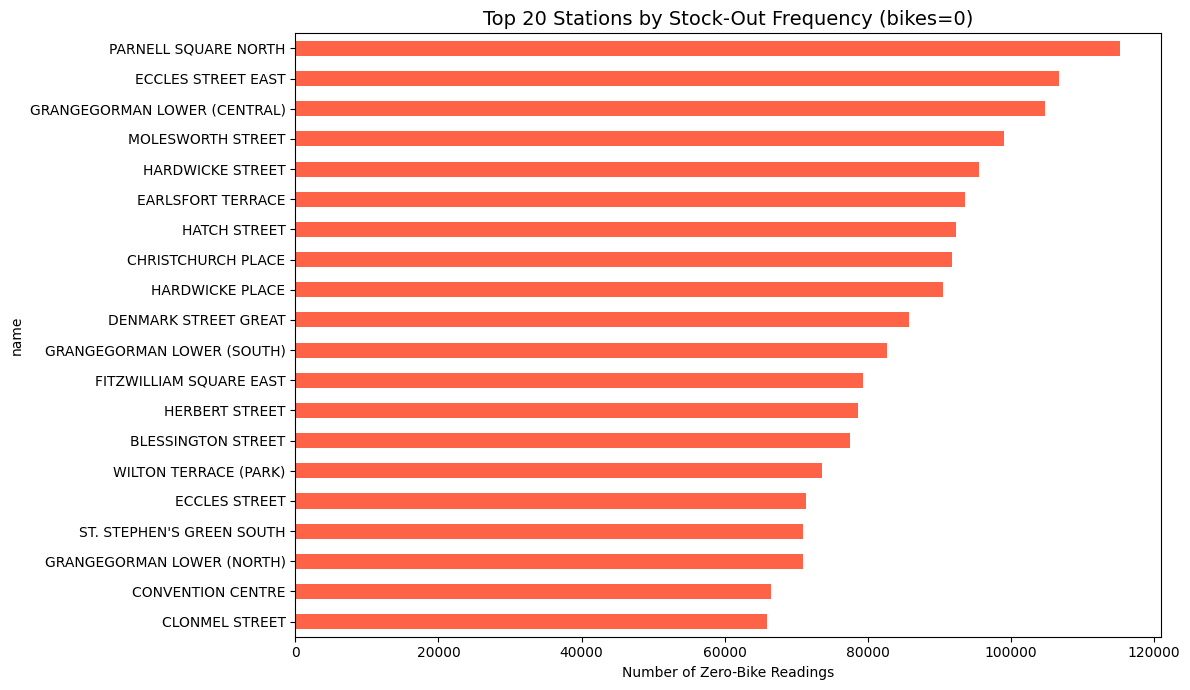

In [8]:
# Compute per station: this is a small aggregation, no memory issue
df["is_stockout"] = (df["bikes"] == 0).astype("int8")
stockout_counts = df.groupby("name", observed=True)["is_stockout"].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 7))
stockout_counts.plot(kind="barh", color="tomato")
plt.title("Top 20 Stations by Stock-Out Frequency (bikes=0)", fontsize=14)
plt.xlabel("Number of Zero-Bike Readings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Dublin Map of Average Occupancy by Station

Stations to plot: 117


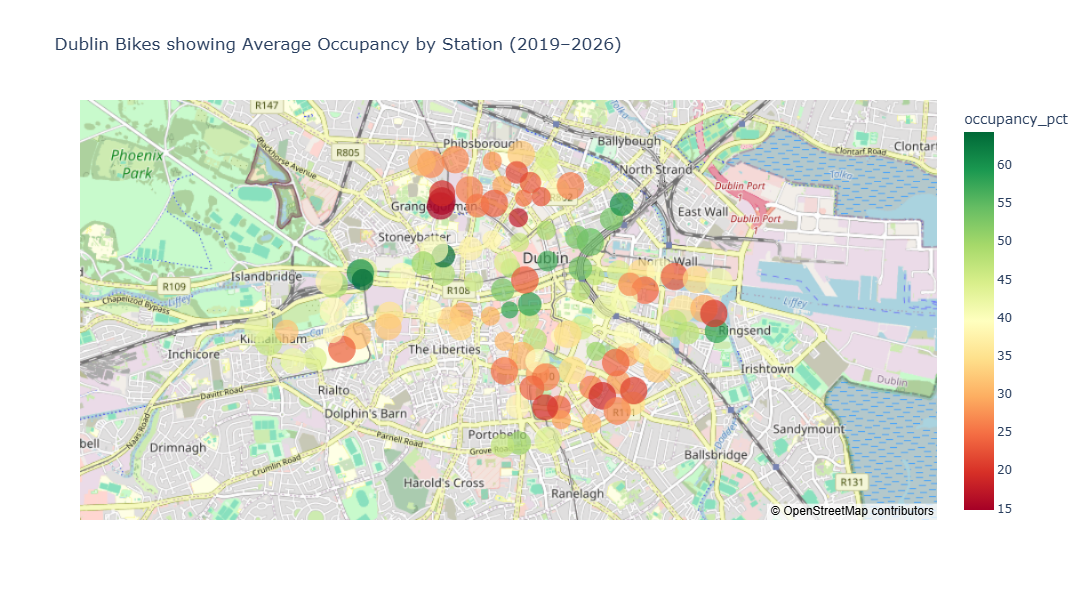

In [9]:
# Aggregate FIRST to a tiny dataframe (118 rows) then plot
# This avoids the MemoryError from running groupby on 51M rows with lat/lon
station_avg = (
    df.groupby("station_id")
    .agg(
        name=("name", "first"),
        lat=("lat", "first"),
        lon=("lon", "first"),
        avg_bikes=("bikes", "mean"),
        capacity=("capacity", "first")
    )
    .reset_index()
)

station_avg["occupancy_pct"] = (station_avg["avg_bikes"] / station_avg["capacity"] * 100).round(1)
station_avg["name"] = station_avg["name"].astype(str)

print(f"Stations to plot: {len(station_avg)}")

fig = px.scatter_map(
    station_avg,
    lat="lat",
    lon="lon",
    color="occupancy_pct",
    size="capacity",
    hover_name="name",
    hover_data={"avg_bikes": ":.1f", "occupancy_pct": ":.1f"},
    color_continuous_scale="RdYlGn",
    map_style="open-street-map",
    zoom=12,
    center={"lat": 53.344, "lon": -6.267},
    title="Dublin Bikes showing Average Occupancy by Station (2019–2026)"
)
fig.update_layout(height=600)
fig.show()

## 6. Stock-Out Rate by Year: Has It Changed Over Time?

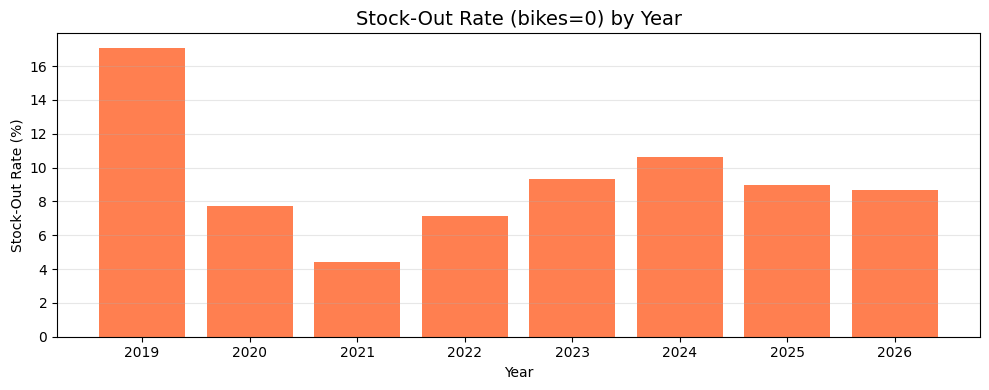

      total_readings  stockout_readings  stockout_rate_pct
year                                                      
2019        10587311            1808244              17.08
2020        10893503             844659               7.75
2021        11138103             490637               4.41
2022         1969246             139997               7.11
2023         1984659             184978               9.32
2024         4664355             496873              10.65
2025         7309842             656837               8.99
2026         2712113             236081               8.70


In [10]:
yearly = df.groupby("year").agg(
    total_readings=("bikes", "count"),
    stockout_readings=("is_stockout", "sum")
)

yearly["stockout_rate_pct"] = (yearly["stockout_readings"] / yearly["total_readings"] * 100).round(2)

plt.figure(figsize=(10, 4))
plt.bar(yearly.index, yearly["stockout_rate_pct"], color="coral")
plt.title("Stock-Out Rate (bikes=0) by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Stock-Out Rate (%)")
plt.xticks(yearly.index)
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(yearly)

## 7. Fullness Rate by Station: Top 20 Stations That Fill Up

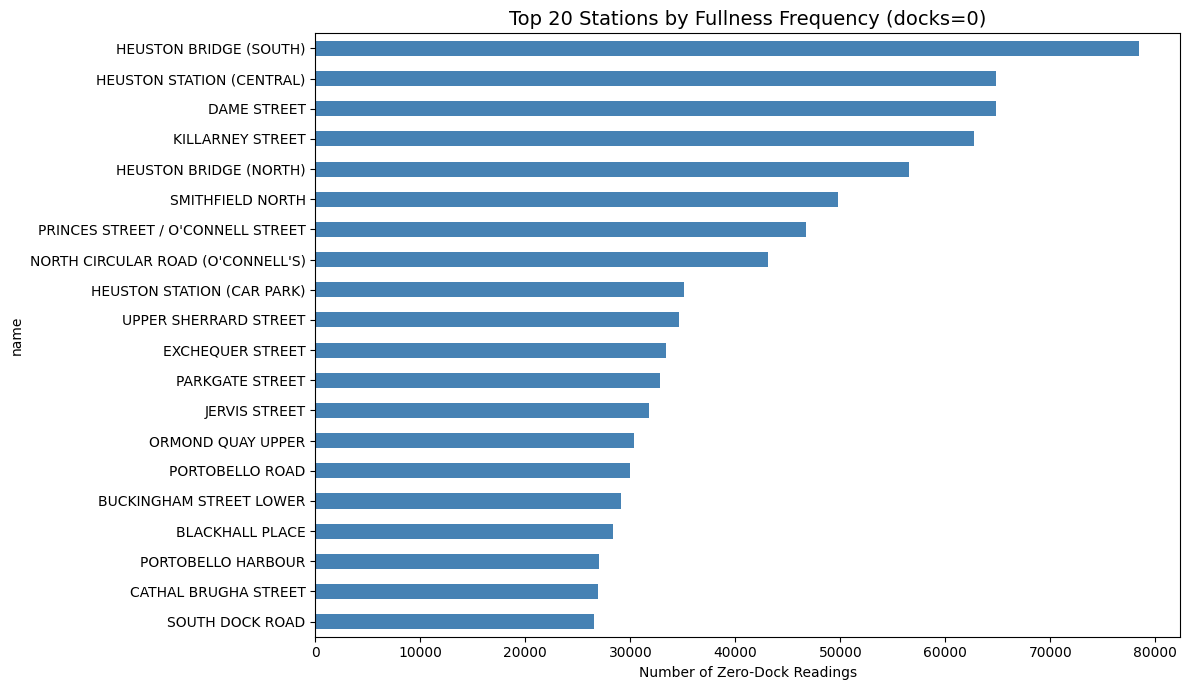

In [11]:
df["is_fullness"] = (df["docks"] == 0).astype("int8")

fullness_counts = (
    df.groupby("name", observed=True)["is_fullness"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)
        
plt.figure(figsize=(12, 7))
fullness_counts.plot(kind="barh", color="steelblue")
plt.title("Top 20 Stations by Fullness Frequency (docks=0)", fontsize=14)
plt.xlabel("Number of Zero-Dock Readings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()